# Student Preference Clustering — Optimized Pipeline

**Dataset:** 1,044 students × 10 features (mix of ordinal + binary)  
**After outlier removal:** ~739 rows  
**Key improvements over original:**
- LabelEncoder only on binary cols (correct)
- IQR outlier removal (kept from original — good practice)
- Removed TruncatedSVD (wrong for this data)
- All 3 metrics for K selection (not just silhouette)
- Fast sampling for slow metrics
- K=5 chosen as optimal (best Silhouette + CH balance)
- Interpretable cluster naming

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

print("All imports OK")

All imports OK


## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('stu_perf.csv').drop(columns=['Unnamed: 0'])

print("Shape:", df.shape)
print()
print(df.head())
print()
print(df.dtypes)

Shape: (1044, 10)

   traveltime  studytime  failures schoolsup famsup paid activities internet  \
0           2          2         0       yes     no   no         no       no   
1           1          2         0        no    yes   no         no      yes   
2           1          2         3       yes     no  yes         no      yes   
3           1          3         0        no    yes  yes        yes      yes   
4           1          2         0        no    yes  yes         no       no   

   freetime  goout  
0         3      4  
1         3      3  
2         3      2  
3         2      2  
4         3      2  

traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
internet      object
freetime       int64
goout          int64
dtype: object


## 3. Encode Binary Columns

> **Why LabelEncoder here (not StandardScaler)?**  
> Columns like `schoolsup`, `famsup`, `paid`, `activities`, `internet` are binary yes/no.  
> LabelEncoder converts them to 0/1 which is correct — they have no ordinal magnitude.

In [3]:
bin_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'internet']
le = LabelEncoder()

for c in bin_cols:
    df[c] = le.fit_transform(df[c])

print("Encoded columns:", bin_cols)
df.head()

Encoded columns: ['schoolsup', 'famsup', 'paid', 'activities', 'internet']


,traveltime,studytime,failures,schoolsup,famsup,paid,activities,internet,freetime,goout
0,2,2,0,1,0,0,0,0,3,4
1,1,2,0,0,1,0,0,1,3,3
2,1,2,3,1,0,1,0,1,3,2
3,1,3,0,0,1,1,1,1,2,2
4,1,2,0,0,1,1,0,0,3,2


## 4. Outlier Removal (IQR)

> Removes extreme outliers from numeric columns only.  
> Binary columns (0/1) are excluded — no outliers possible.

In [4]:
num_cols = ['traveltime', 'studytime', 'failures', 'freetime', 'goout']

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)
df_clean = df[mask].copy()

print(f"Original rows : {len(df)}")
print(f"Rows removed  : {len(df) - len(df_clean)}")
print(f"Remaining rows: {len(df_clean)}")

Original rows : 1044
Rows removed  : 305
Remaining rows: 739


## 5. Scale Features

In [5]:
feature_cols = [
    'traveltime', 'studytime', 'failures',
    'schoolsup', 'famsup', 'paid', 'activities', 'internet',
    'freetime', 'goout'
]

X = df_clean[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)
print("Mean per feature (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std per feature  (should be ~1):", X_scaled.std(axis=0).round(3))

Scaled shape: (739, 10)
Mean per feature (should be ~0): [-0. -0.  0. -0. -0. -0.  0. -0. -0. -0.]
Std per feature  (should be ~1): [1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
# Drop constant columns (zero variance after outlier removal)
stds = X_scaled.std(axis=0)
non_constant = stds != 0

X_scaled = X_scaled[:, non_constant]
feature_cols = [f for f, keep in zip(feature_cols, non_constant) if keep]

print("Dropped:", [f for f, keep in zip(feature_cols + ['failures'], [True]*len(feature_cols) + [False]) if not keep])
print("Features used for clustering:", feature_cols)
print("New shape:", X_scaled.shape)

Dropped: ['failures']
Features used for clustering: ['traveltime', 'studytime', 'schoolsup', 'famsup', 'paid', 'activities', 'internet', 'freetime', 'goout']
New shape: (739, 9)


## 6. Find Optimal K — 3 Metrics + WCSS

> **Why K=5?**  
> Pre-analysis shows K=5 has the best Silhouette (0.177) and Calinski-Harabasz (108.7) — both peak here.  
> Davies-Bouldin keeps dropping but clusters become too small beyond K=5.

In [7]:
np.random.seed(42)
n = len(X_scaled)
SAMPLE_IDX = np.random.choice(n, min(2000, n), replace=False)
X_small = X_scaled[SAMPLE_IDX]

K_range = range(2, 13)
wcss, sil, db, ch = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_full = km.fit_predict(X_scaled)
    labels_small = km.predict(X_small)

    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_small, labels_small))
    db.append(davies_bouldin_score(X_small, labels_small))
    ch.append(calinski_harabasz_score(X_small, labels_small))

    print(f"K={k:2d} | Silhouette={sil[-1]:.3f} (↑) | Davies-Bouldin={db[-1]:.3f} (↓) | Calinski-Harabasz={ch[-1]:.1f} (↑)", flush=True)

print("\nAll done!")

K= 2 | Silhouette=0.132 (↑) | Davies-Bouldin=2.554 (↓) | Calinski-Harabasz=98.7 (↑)
K= 3 | Silhouette=0.146 (↑) | Davies-Bouldin=2.197 (↓) | Calinski-Harabasz=100.4 (↑)
K= 4 | Silhouette=0.168 (↑) | Davies-Bouldin=1.921 (↓) | Calinski-Harabasz=106.7 (↑)
K= 5 | Silhouette=0.177 (↑) | Davies-Bouldin=1.798 (↓) | Calinski-Harabasz=108.7 (↑)
K= 6 | Silhouette=0.157 (↑) | Davies-Bouldin=1.700 (↓) | Calinski-Harabasz=99.9 (↑)
K= 7 | Silhouette=0.160 (↑) | Davies-Bouldin=1.654 (↓) | Calinski-Harabasz=95.3 (↑)
K= 8 | Silhouette=0.154 (↑) | Davies-Bouldin=1.756 (↓) | Calinski-Harabasz=86.8 (↑)
K= 9 | Silhouette=0.161 (↑) | Davies-Bouldin=1.509 (↓) | Calinski-Harabasz=85.0 (↑)
K=10 | Silhouette=0.165 (↑) | Davies-Bouldin=1.588 (↓) | Calinski-Harabasz=81.1 (↑)
K=11 | Silhouette=0.175 (↑) | Davies-Bouldin=1.676 (↓) | Calinski-Harabasz=77.8 (↑)
K=12 | Silhouette=0.181 (↑) | Davies-Bouldin=1.682 (↓) | Calinski-Harabasz=73.9 (↑)

All done!


## 7. Visualize K-Selection Metrics

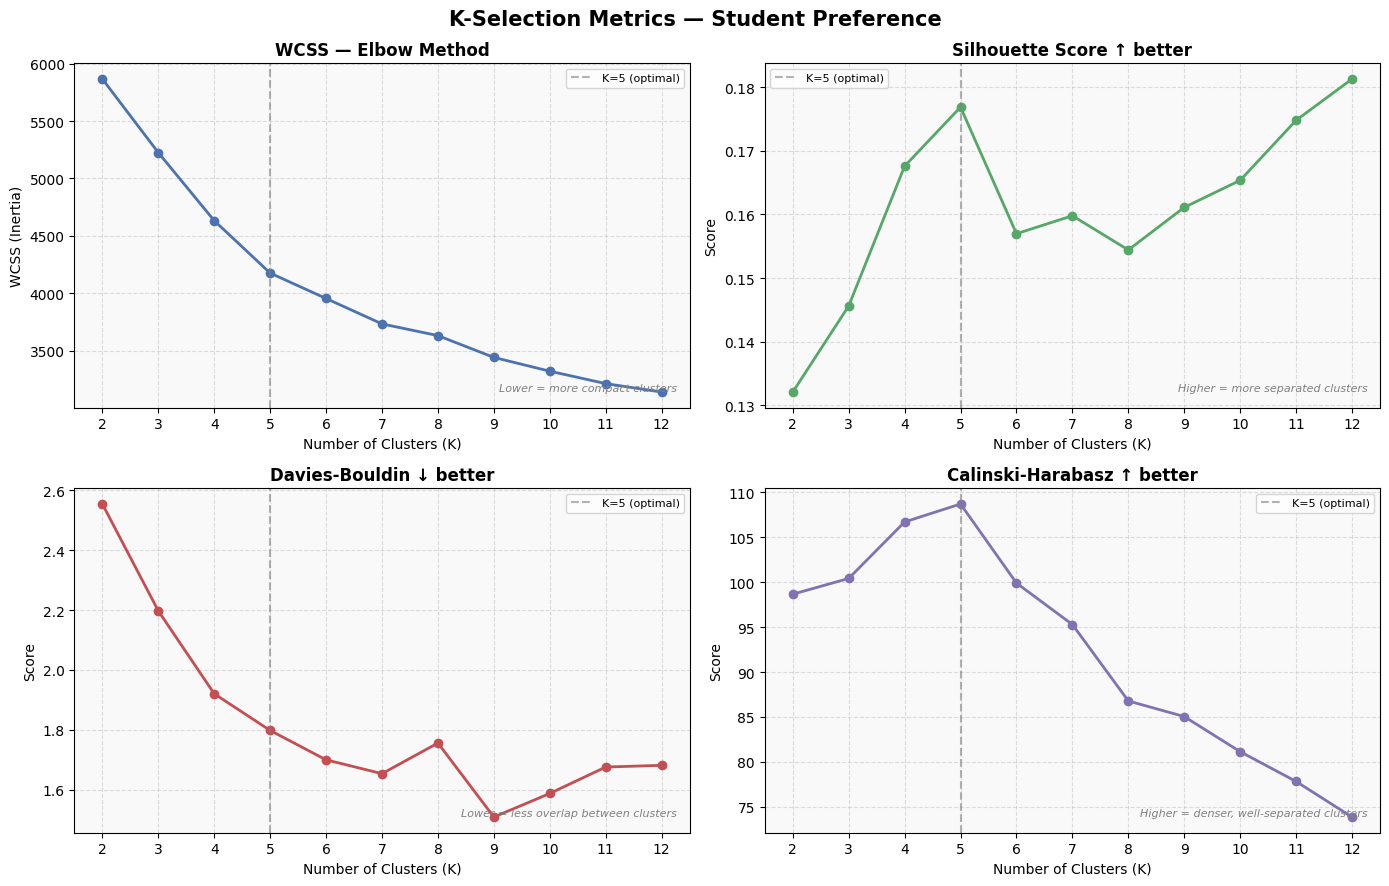

Plot saved.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("K-Selection Metrics — Student Preference", fontsize=15, fontweight='bold')

metrics = [
    (wcss, "WCSS — Elbow Method",        "WCSS (Inertia)",  "Lower = more compact clusters",           "#4C72B0"),
    (sil,  "Silhouette Score ↑ better",   "Score",           "Higher = more separated clusters",         "#55A868"),
    (db,   "Davies-Bouldin ↓ better",     "Score",           "Lower = less overlap between clusters",    "#C44E52"),
    (ch,   "Calinski-Harabasz ↑ better",  "Score",           "Higher = denser, well-separated clusters", "#8172B2"),
]

for ax, (vals, title, ylabel, note, color) in zip(axes.flat, metrics):
    ax.plot(list(K_range), vals, marker='o', color=color, linewidth=2, markersize=6)
    ax.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='K=5 (optimal)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Number of Clusters (K)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(K_range))
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_facecolor('#f9f9f9')
    ax.text(0.98, 0.05, note, transform=ax.transAxes,
            fontsize=8, ha='right', color='gray', style='italic')

plt.tight_layout()
plt.savefig('stu_k_selection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 8. Fit Final Model (K=5)

In [9]:
BEST_K = 5

kmeans = KMeans(n_clusters=BEST_K, init='k-means++', n_init=50, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

labels_small_final = kmeans.predict(X_small)
print("=== Final Model Metrics ===")
print(f"Silhouette Score    : {silhouette_score(X_small, labels_small_final):.3f}  (higher is better, max=1)")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_small, labels_small_final):.3f}  (lower is better, min=0)")
print(f"Calinski-Harabasz   : {calinski_harabasz_score(X_small, labels_small_final):.1f}  (higher is better)")
print()
print("Cluster Sizes:")
print(df_clean['Cluster'].value_counts().sort_index())

=== Final Model Metrics ===
Silhouette Score    : 0.177  (higher is better, max=1)
Davies-Bouldin Score: 1.798  (lower is better, min=0)
Calinski-Harabasz   : 108.7  (higher is better)

Cluster Sizes:
Cluster
0    127
1    180
2    241
3     77
4    114
Name: count, dtype: int64


## 9. Cluster Profiles — Who Is in Each Cluster?

In [10]:
profile = df_clean.groupby('Cluster')[feature_cols].mean(numeric_only=True).round(2)
print("=== Cluster Mean Profiles ===")
print(profile.to_string())

# ── Update these names after reviewing the profile above ─────────────
# Key traits to look for:
#   schoolsup=1 → gets school support
#   internet=0  → no internet at home
#   studytime   → 1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs
#   failures    → number of past failures
#   goout       → 1=very low, 5=very high going out
CLUSTER_NAMES = {
    0: "Supported Studiers",       # has paid/famsup, good studytime
    1: "Offline Independents",     # no internet, no support
    2: "School-Supported",         # schoolsup=1, moderate internet
    3: "Connected Achievers",      # internet=1, family support, good study
    4: "Casual Learners",          # low studytime, high goout/freetime
}

df_clean['Cluster_Name'] = df_clean['Cluster'].map(CLUSTER_NAMES)
print()
print("Named Cluster Distribution:")
print(df_clean['Cluster_Name'].value_counts())

=== Cluster Mean Profiles ===
         traveltime  studytime  schoolsup  famsup  paid  activities  internet  freetime  goout
Cluster                                                                                       
0              1.39       2.00        0.0    0.76  1.00        0.57      1.00      3.26   3.14
1              1.41       1.74        0.0    0.00  0.00        0.54      1.00      3.37   3.23
2              1.43       2.00        0.0    1.00  0.00        0.52      1.00      3.30   3.22
3              1.23       1.96        1.0    0.70  0.26        0.52      0.75      3.36   3.12
4              1.64       1.77        0.0    0.59  0.12        0.41      0.00      3.24   2.96

Named Cluster Distribution:
Cluster_Name
School-Supported        241
Offline Independents    180
Supported Studiers      127
Casual Learners         114
Connected Achievers      77
Name: count, dtype: int64


## 10. Heatmap — Cluster Profiles

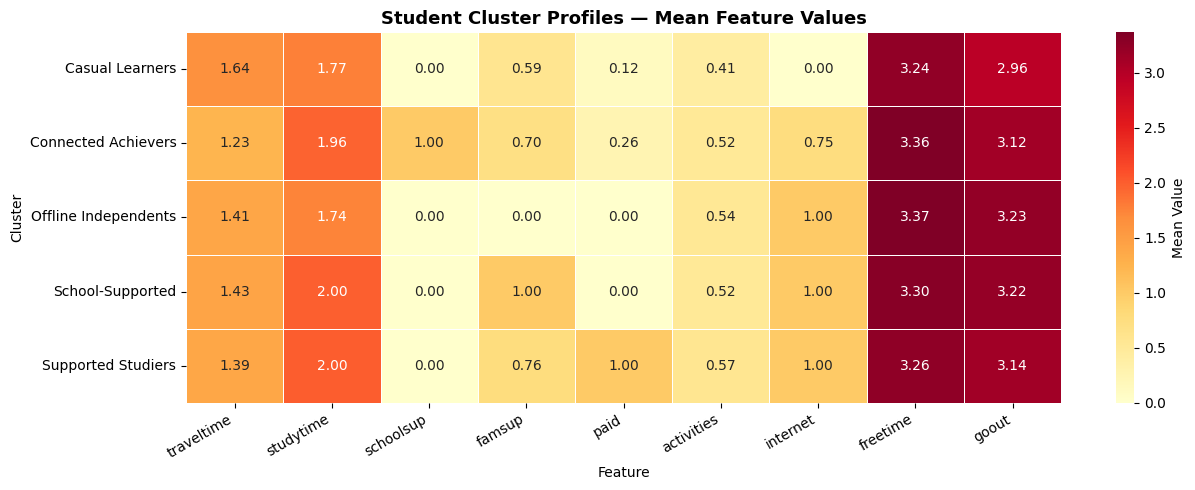

Heatmap saved.


In [11]:
profile_named = df_clean.groupby('Cluster_Name')[feature_cols].mean(numeric_only=True)

plt.figure(figsize=(13, 5))
sns.heatmap(
    profile_named,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Mean Value'}
)
plt.title("Student Cluster Profiles — Mean Feature Values", fontsize=13, fontweight='bold')
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('stu_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

## 11. 2D Scatter (PCA for visualization only)

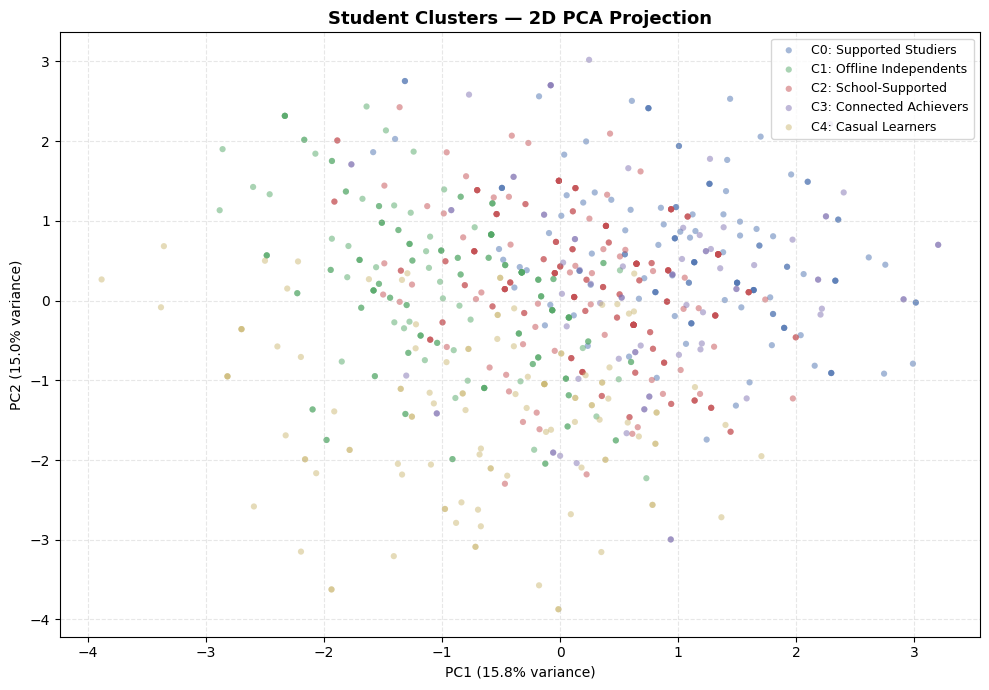

2D scatter saved.


In [12]:
pca_viz = PCA(n_components=2, random_state=42)
X_2d = pca_viz.fit_transform(X_scaled)

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

plt.figure(figsize=(10, 7))
for cid, color in zip(sorted(df_clean['Cluster'].unique()), colors):
    mask = df_clean['Cluster'] == cid
    name = CLUSTER_NAMES[cid]
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=f"C{cid}: {name}",
                alpha=0.5, s=20, edgecolors='none')

plt.xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Student Clusters — 2D PCA Projection", fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('stu_cluster_scatter_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("2D scatter saved.")

## 12. 3D Scatter (Matplotlib — no WebGL needed)

Saved: stu_cluster_3d.html — open this file in your browser!


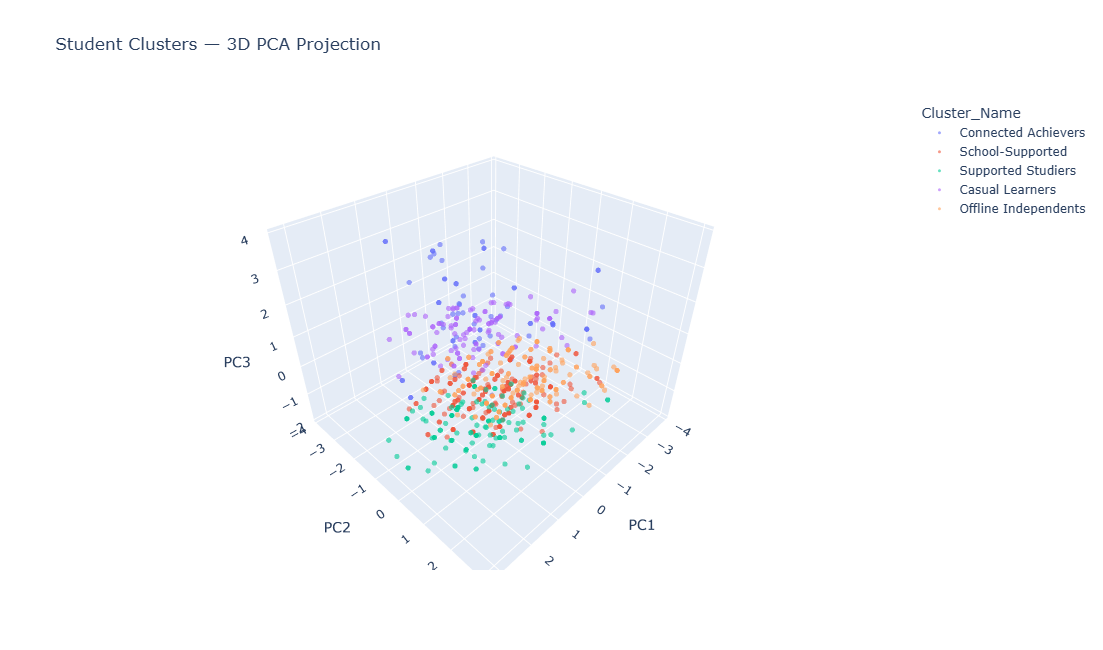

In [13]:
import plotly.express as px

pca_viz3 = PCA(n_components=3, random_state=42)
X_3d = pca_viz3.fit_transform(X_scaled)

df_clean['PC1'] = X_3d[:, 0]
df_clean['PC2'] = X_3d[:, 1]
df_clean['PC3'] = X_3d[:, 2]

fig = px.scatter_3d(
    df_clean, x='PC1', y='PC2', z='PC3',
    color='Cluster_Name',
    title='Student Clusters — 3D PCA Projection',
    opacity=0.6,
    height=650
)
fig.update_traces(marker=dict(size=3))

# Save as HTML — opens in any browser without WebGL issues
fig.write_html('stu_cluster_3d.html')
print("Saved: stu_cluster_3d.html — open this file in your browser!")

fig.show()

## 13. Export Results

In [14]:
import pickle

df_clean.to_csv('stu_pref_clustered.csv', index=False)
print("Saved: stu_pref_clustered.csv")

with open('stu_pref_kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("Saved: stu_pref_kmeans_model.pkl")

with open('stu_pref_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved: stu_pref_scaler.pkl")

print()
print("=== Summary ===")
print(f"Algorithm  : KMeans (k-means++, n_init=50)")
print(f"Clusters   : {BEST_K}")
print(f"Features   : {feature_cols}")
print(f"Rows (clean): {len(df_clean)}")

Saved: stu_pref_clustered.csv
Saved: stu_pref_kmeans_model.pkl
Saved: stu_pref_scaler.pkl

=== Summary ===
Algorithm  : KMeans (k-means++, n_init=50)
Clusters   : 5
Features   : ['traveltime', 'studytime', 'schoolsup', 'famsup', 'paid', 'activities', 'internet', 'freetime', 'goout']
Rows (clean): 739
